<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/add%2Fmodel3/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/main/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Activation, LeakyReLU
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
import random
import numpy as np

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [4]:
# generators
train_ds  = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

validation_ds =  keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
)

Found 2728 files belonging to 62 classes.
Found 682 files belonging to 62 classes.


In [5]:
aug_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/augmented_images/augmented_images1",
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

Found 13640 files belonging to 62 classes.


In [6]:
#normalize
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [7]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [8]:
aug_ds = aug_ds.map(process)

images, label = next(iter(aug_ds))
images.shape, label.shape

(TensorShape([64, 128, 128, 3]), TensorShape([64]))

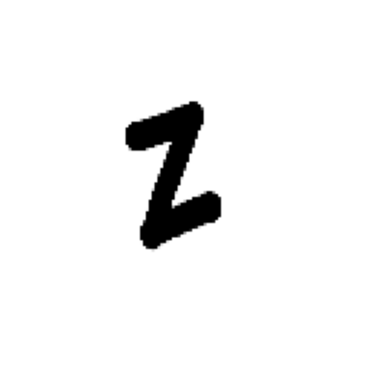

In [9]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [10]:
images, labels = next(iter(train_ds))
images.shape, labels.shape

(TensorShape([32, 128, 128, 3]), TensorShape([32]))

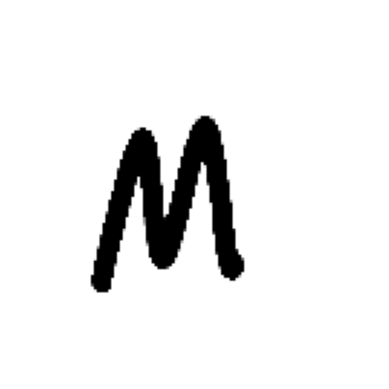

In [11]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [12]:
def accuracy_vs_epochs(history):
  plt.plot(history.history['accuracy'], label='accuracy')
  plt.plot(history.history['val_accuracy'], label='val_accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.ylim(0, 1)
  plt.legend(loc='lower right')
  plt.show()

In [13]:
import pickle


BASE_PATH = '/content/drive/MyDrive/handwritten_english_character_and_digits'

def make_callbacks(model_name):
    """Creates a fresh checkpoint + early_stop pair for a given model name."""
    model_dir = f'{BASE_PATH}/{model_name}'
    os.makedirs(model_dir, exist_ok=True)  # creates folder if missing, no error if it exists

    checkpoint_cb = keras.callbacks.ModelCheckpoint(
        f'{model_dir}/{model_name}_checkpoint.keras',
        save_best_only=True,
        monitor='val_loss'
    )
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    return [early_stop, checkpoint_cb]

def save_history(history_obj, model_name, stage):
    """Saves a Keras History object's .history dict to Drive.
    stage e.g. 'original' or 'augmented' """
    model_dir = f'{BASE_PATH}/{model_name}'
    os.makedirs(model_dir, exist_ok=True)

    with open(f'{model_dir}/{model_name}_history_{stage}.pkl', 'wb') as f:
        pickle.dump(history_obj.history, f)
    print(f"Saved: {model_name}_history_{stage}.pkl")

In [14]:
def restore_model(model_name):
    """Loads a saved model checkpoint if it exists, else returns None."""
    path = f'{BASE_PATH}/{model_name}/{model_name}_checkpoint.keras'
    if os.path.exists(path):
        model = keras.models.load_model(path)
        print(f"✅ Restored {model_name} from checkpoint")
        return model
    else:
        print(f"⚠️  No checkpoint found for {model_name} — needs training from scratch")
        return None

def restore_history(model_name, stage):
    """Loads a saved history dict if it exists, else returns None."""
    path = f'{BASE_PATH}/{model_name}/{model_name}_history_{stage}.pkl'
    if os.path.exists(path):
        with open(path, 'rb') as f:
            history = pickle.load(f)
        print(f"✅ Restored {model_name} {stage} history ({len(history['loss'])} epochs)")
        return history
    else:
        print(f"⚠️  No {stage} history found for {model_name}")
        return None

In [15]:
# fiting function for simplicity
def training(model, model_name, training_data, val_ds, stage):
    history = model.fit(
        training_data, epochs=100, validation_data=val_ds,
        callbacks=make_callbacks(model_name)
    )
    save_history(history, model_name, stage)
    return history

In [16]:
#model 1
model1 = Sequential([
    Conv2D(32, (3,3), activation= 'relu', padding = "same", input_shape = (128, 128, 3)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(160, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),

    Dense(62, activation='softmax')
])

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,596,574 (6.09 MB)

 Trainable params: 1,596,574 (6.09 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history1 = training(model1, 'model1', train_ds, validation_ds, 'original')

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 603s 7s/step - accuracy: 0.0825 - loss: 3.8262 - val_accuracy: 0.2903 - val_loss: 2.7464
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - accuracy: 0.4359 - loss: 2.1254 - val_accuracy: 0.5381 - val_loss: 1.7608
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 251ms/step - accuracy: 0.6675 - loss: 1.1571 - val_accuracy: 0.6554 - val_loss: 1.3075
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 266ms/step - accuracy: 0.7966 - loss: 0.6758 - val_accuracy: 0.6848 - val_loss: 1.3581
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 258ms/step - accuracy: 0.8732 - loss: 0.4027 - val_accuracy: 0.6921 - val_loss: 1.5339
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 257ms/step - accuracy: 0.9201 - loss: 0.2590 - val_accuracy: 0.6804 - val_loss: 1.6957
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 249ms/step - accuracy: 0.9465 - loss: 0.1817 - val_accuracy: 0.6935 - val_loss: 1.6186
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.9615 - loss: 0.1162 - va

In [18]:
history1_2 = training(model1, 'model1', aug_ds, validation_ds, 'augmented')

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2534s 12s/step - accuracy: 0.4906 - loss: 1.8850 - val_accuracy: 0.7405 - val_loss: 0.8145
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 105s 489ms/step - accuracy: 0.7625 - loss: 0.7584 - val_accuracy: 0.7771 - val_loss: 0.7230
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 99s 464ms/step - accuracy: 0.8634 - loss: 0.4126 - val_accuracy: 0.8006 - val_loss: 0.6812
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 143s 470ms/step - accuracy: 0.9103 - loss: 0.2593 - val_accuracy: 0.8123 - val_loss: 0.7190
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 139s 453ms/step - accuracy: 0.9378 - loss: 0.1762 - val_accuracy: 0.8314 - val_loss: 0.7050
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 100s 466ms/step - accuracy: 0.9553 - loss: 0.1293 - val_accuracy: 0.8021 - val_loss: 0.8286
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 98s 457ms/step - accuracy: 0.9630 - loss: 0.1081 - val_accuracy: 0.8123 - val_loss: 0.8730
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 101s 473ms/step - accuracy: 0.9

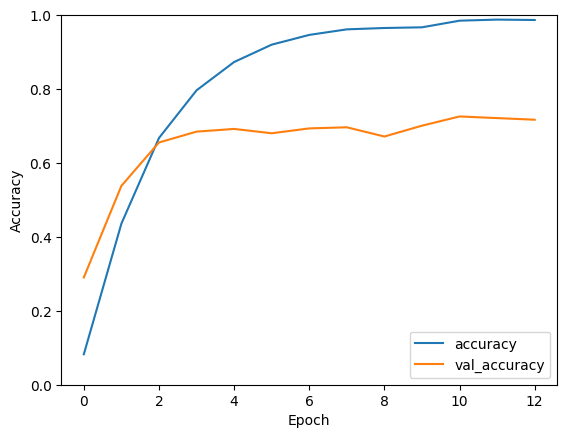

In [19]:
accuracy_vs_epochs(history1)

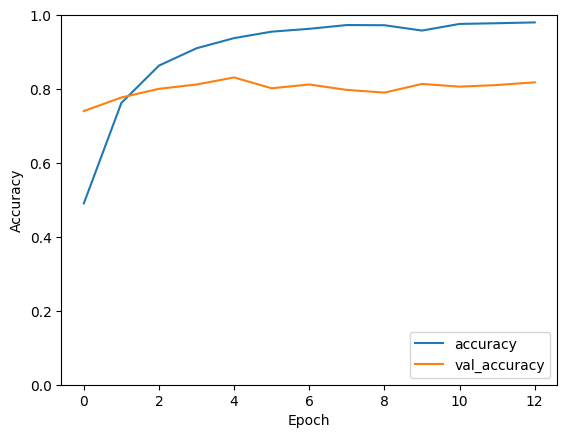

In [20]:
accuracy_vs_epochs(history1_2)

In [21]:
#model 2
model2 = Sequential([
    Conv2D(32, (3,3), activation= 'relu',  input_shape = (128, 128, 3)),

    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(64, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(128, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(160, (3,3), activation= 'relu'),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Flatten(),
    Dense(64, activation='relu'),

    Dense(62, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,462 (2.48 MB)

 Trainable params: 650,462 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history2 = training(model2, 'model2', train_ds, validation_ds, 'original')

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.0301 - loss: 4.0745 - val_accuracy: 0.0762 - val_loss: 3.7410
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 264ms/step - accuracy: 0.2317 - loss: 3.0548 - val_accuracy: 0.4003 - val_loss: 2.2401
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 247ms/step - accuracy: 0.5301 - loss: 1.6942 - val_accuracy: 0.5601 - val_loss: 1.6061
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 276ms/step - accuracy: 0.7100 - loss: 1.0137 - val_accuracy: 0.6584 - val_loss: 1.2402
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 267ms/step - accuracy: 0.7944 - loss: 0.6633 - val_accuracy: 0.6730 - val_loss: 1.2282
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 241ms/step - accuracy: 0.8622 - loss: 0.4343 - val_accuracy: 0.6701 - val_loss: 1.4819
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 244ms/step - accuracy: 0.8977 - loss: 0.3236 - val_accuracy: 0.6789 - val_loss: 1.4842
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 261ms/step - accuracy: 0.9249 - loss: 0.2324 - 

In [23]:
history21= training(model2, 'model2', aug_ds, validation_ds, 'augmented')

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 96s 447ms/step - accuracy: 0.4876 - loss: 1.9029 - val_accuracy: 0.7595 - val_loss: 0.7421
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 94s 441ms/step - accuracy: 0.7163 - loss: 0.8964 - val_accuracy: 0.8050 - val_loss: 0.6099
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 143s 448ms/step - accuracy: 0.8223 - loss: 0.5456 - val_accuracy: 0.7977 - val_loss: 0.6128
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 96s 447ms/step - accuracy: 0.8741 - loss: 0.3677 - val_accuracy: 0.8167 - val_loss: 0.6690
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 97s 450ms/step - accuracy: 0.9097 - loss: 0.2546 - val_accuracy: 0.8079 - val_loss: 0.7313
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 96s 450ms/step - accuracy: 0.9399 - loss: 0.1789 - val_accuracy: 0.8240 - val_loss: 0.7624
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 95s 442ms/step - accuracy: 0.9464 - loss: 0.1477 - val_accuracy: 0.8109 - val_loss: 0.7845
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 94s 438ms/step - accuracy: 0.9518 

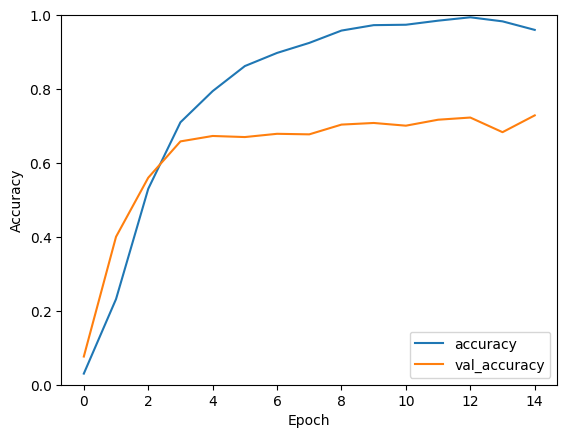

In [24]:
accuracy_vs_epochs(history2)

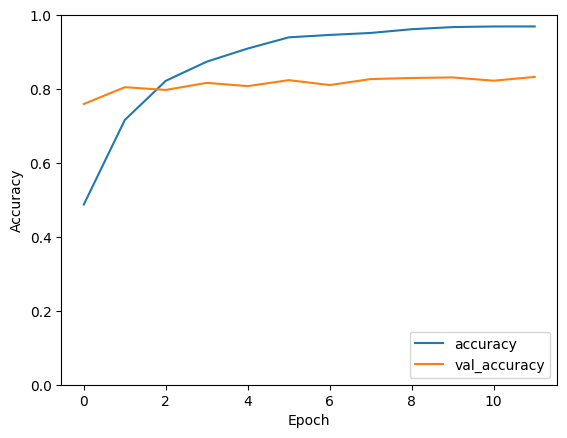

In [25]:
accuracy_vs_epochs(history21)

## Overfitting and Data Augmentation

Our initial models suffered from **overfitting**, partly due to the relatively small original training set of around 2,000 images. With limited data, a CNN can memorize training examples rather than learning features that generalize to unseen samples.

To address this, we continued training each model on an **augmented dataset** of ~13,000 images, generated via small rotations, shifts, and zooms. This exposes the model to more variation and encourages it to learn features that don't depend on the exact pose or position of the original samples.

This round of training also introduced **checkpointing** (`ModelCheckpoint`, saving best weights by `val_loss`) and **early stopping** (`patience=10`, `restore_best_weights=True`). Because weights are restored based on lowest `val_loss` rather than highest `val_accuracy`, the reported figures below reflect the model's performance *at that restored checkpoint*, not the peak accuracy observed at any point during training.

### Model 1

On the original dataset, Model 1's lowest val_loss (1.3075) occurred at epoch 3, corresponding to a validation accuracy of **65.54%**. Continuing on the augmented dataset, the lowest val_loss (0.6812) occurred at epoch 3, corresponding to **80.06%** validation accuracy.

Training accuracy continued climbing well past this point (to 97.81% by epoch 13), while val_loss also climbed after epoch 3 — from 0.68 up to 1.12 — even as val_accuracy briefly touched higher values (83.14% at epoch 5) before declining again. This is a clear overfitting signature: the model's most *confident and reliable* checkpoint is not its highest-accuracy epoch.

### Model 2

On the original dataset, Model 2's lowest val_loss (1.2282) occurred at epoch 5, corresponding to **67.30%** validation accuracy. On the augmented dataset, the lowest val_loss (0.6099) occurred very early — epoch 2 — corresponding to **80.50%** validation accuracy.

As with Model 1, later epochs reached higher raw accuracy (up to 83.28% at epoch 12) but at steadily increasing val_loss, meaning those later checkpoints are less trustworthy despite the higher accuracy number.

### Comparison (restored checkpoint — lowest val_loss)

| Model | Original Data (val acc @ best val_loss) | Augmented Data (val acc @ best val_loss) | Best val_loss (augmented) |
|-------|---------------:|---------------:|---------------:|
| Model 1 | 65.54% (epoch 3) | 80.06% (epoch 3) | 0.6812 |
| Model 2 | 67.30% (epoch 5) | 80.50% (epoch 2) | **0.6099** |

Model 2 remains marginally ahead of Model 1 at their respective best-val_loss checkpoints, both in accuracy and in loss. Notably, both models' lowest-loss checkpoints occur early in the augmented-data run (epoch 2–3), well before training accuracy plateaus — reinforcing that **letting training run longer does not mean the model keeps improving on unseen data**, and that `val_loss` is a more trustworthy stopping signal than `val_accuracy` alone.

This motivates the next phase of experiments: Model 3 introduces BatchNormalization + Dropout + a reduced learning rate, and Models 4–6 explore LeakyReLU (with and without BatchNormalization) to address a dying-ReLU collapse observed during Model 3's initial training, and to isolate which architectural change actually improves generalization rather than just raw peak accuracy.

In [ ]:
# model 3 model2 + batchnormalization + dropout + custom learning rate
model3 = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(64, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(128, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(160, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(62, activation='softmax')
])
model3.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 160)    │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 12, 12, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,998 (2.49 MB)

 Trainable params: 651,230 (2.48 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
history3 = training(model3, 'model3', train_ds, validation_ds, 'original')

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 252ms/step - accuracy: 0.0389 - loss: 4.1085 - val_accuracy: 0.0161 - val_loss: 4.1358
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 250ms/step - accuracy: 0.0649 - loss: 3.8863 - val_accuracy: 0.0161 - val_loss: 4.1880
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.1004 - loss: 3.6667 - val_accuracy: 0.0176 - val_loss: 4.1916
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 229ms/step - accuracy: 0.1510 - loss: 3.4703 - val_accuracy: 0.0205 - val_loss: 4.0574
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/step - accuracy: 0.1946 - loss: 3.2408 - val_accuracy: 0.0909 - val_loss: 3.8167
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 254ms/step - accuracy: 0.2449 - loss: 3.0452 - val_accuracy: 0.2273 - val_loss: 3.4122
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - accuracy: 0.2936 - loss: 2.7952 - val_accuracy: 0.3109 - val_loss: 3.0998
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 228ms/step - accuracy: 0.3457 - loss: 2.5885 - 

In [ ]:
history3_1 = training(model3, 'model3', aug_ds, validation_ds, 'augmented')

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2603s 12s/step - accuracy: 0.2016 - loss: 3.3007 - val_accuracy: 0.5557 - val_loss: 1.6859
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 148s 414ms/step - accuracy: 0.2896 - loss: 2.7249 - val_accuracy: 0.6320 - val_loss: 1.3755
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 140s 407ms/step - accuracy: 0.3436 - loss: 2.4352 - val_accuracy: 0.7346 - val_loss: 1.0661
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 142s 405ms/step - accuracy: 0.3923 - loss: 2.2006 - val_accuracy: 0.7390 - val_loss: 1.0135
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 89s 413ms/step - accuracy: 0.4342 - loss: 2.0004 - val_accuracy: 0.7199 - val_loss: 1.0118
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 87s 407ms/step - accuracy: 0.4695 - loss: 1.8345 - val_accuracy: 0.7185 - val_loss: 0.9844
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 89s 413ms/step - accuracy: 0.5048 - loss: 1.7069 - val_accuracy: 0.6891 - val_loss: 1.0706
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 411ms/step - accuracy: 0.537

In [ ]:
accuracy_vs_epochs(history3)

NameError: name 'accuracy_vs_epochs' is not defined

In [ ]:
# model 4 model2 + batchnormalization + dropout + custom learning rate + LeakyReLU as activation
model4 = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(64, (3,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(128, (3,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(160, (3,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(62, activation='softmax')
])
model4.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model4.summary()

In [ ]:
# model 5 model2 +  dropout + custom learning rate + LeakyReLU as activation
model5 = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(64, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(128, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(160, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(62, activation='softmax')
])
model5.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model5.summary()

In [ ]:
# model 6 model1 +  dropout + custom learning rate + LeakyReLU as activation
model6 = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(64, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(128, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(160, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(62, activation='softmax')
])
model6.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model6.summary()